# 🧹 Data Cleaning — Complete Reference Notebook
> **Purpose:** A full, reproducible reference for every step of data cleaning in a machine learning pipeline.  
> Covers: junk detection, type coercion, negative values, domain constraints, duplicates, missing value imputation, outlier visualisation, and export.

---
**Dataset:** `ml_learning_dataset.csv` — 500 rows, 13 columns, intentionally injected with:
- Missing values (`NaN`, blank cells)
- Junk tokens (`?`, `-`, `N/A`, `--`, `#`, `null`)
- Extreme outliers (e.g. `999999`, `-88888`)

**Target column:** `annual_salary` (continuous — used later for regression)


## 0 · Imports & Global Settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings('ignore')

# Prettier pandas output
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 1 · Load the Dataset

In [2]:
# ── Change this path to wherever your CSV lives ──────────────────────────────
PATH_RAW = "/home/silvy_linux/Desktop/Internship/Assignments/Claude/uncleaned_data.csv"
# ─────────────────────────────────────────────────────────────────────────────

# Everything is read as strings first so we can catch non-numeric junk ourselves
df = pd.read_csv(PATH_RAW, dtype=str)

print(f"Shape  : {df.shape}  (rows × columns)")
print(f"Columns: {list(df.columns)}")
df.head(5)


Shape  : (500, 13)  (rows × columns)
Columns: ['age', 'experience_yrs', 'education_yrs', 'hours_per_week', 'iq_score', 'city_population', 'distance_to_office_km', 'avg_temp_celsius', 'prev_salary', 'bonus_pct', 'dept_code', 'gender_code', 'annual_salary']


,age,experience_yrs,education_yrs,hours_per_week,iq_score,city_population,distance_to_office_km,avg_temp_celsius,prev_salary,bonus_pct,dept_code,gender_code,annual_salary
0,33.6,11.3,14,40.1,108.2,762775.0,29.86,13.02,40490.88,0.95,1,0,57229.54
1,48.5,26.6,16,36.3,123.9,721463.0,5.58,14.3,43110.7,29.19,4,0,82097.8
2,32.5,13.3,14,43.9,112.0,350410.0,6.36,20.91,40777.82,19.05,5,0,68130.18
3,43.4,22.6,20,35.1,68.8,502008.0,16.54,18.96,57680.54,16.17,5,1,76805.04
4,NaN,0,18,39.9,119.0,782491.0,14.66,32.94,61445.12,22.53,3,0,61478.73


## 2 · Quick Snapshot Before Touching Anything

In [3]:
print("=== dtypes ===")
print(df.dtypes)
print()
print("=== null counts (raw string nulls — not real NaNs yet) ===")
print(df.isnull().sum())


=== dtypes ===
age                      str
experience_yrs           str
education_yrs            str
hours_per_week           str
iq_score                 str
city_population          str
distance_to_office_km    str
avg_temp_celsius         str
prev_salary              str
bonus_pct                str
dept_code                str
gender_code              str
annual_salary            str
dtype: object

=== null counts (raw string nulls — not real NaNs yet) ===
age                      11
experience_yrs            3
education_yrs             8
hours_per_week           13
iq_score                  5
city_population          10
distance_to_office_km     9
avg_temp_celsius         10
prev_salary              13
bonus_pct                12
dept_code                 8
gender_code               7
annual_salary             0
dtype: int64


## 3 · Visual EDA  *(Before Cleaning)*

> Always plot **before** you clean so you can visually justify every decision.  
> Outliers will literally jump off the chart here — that's the point.


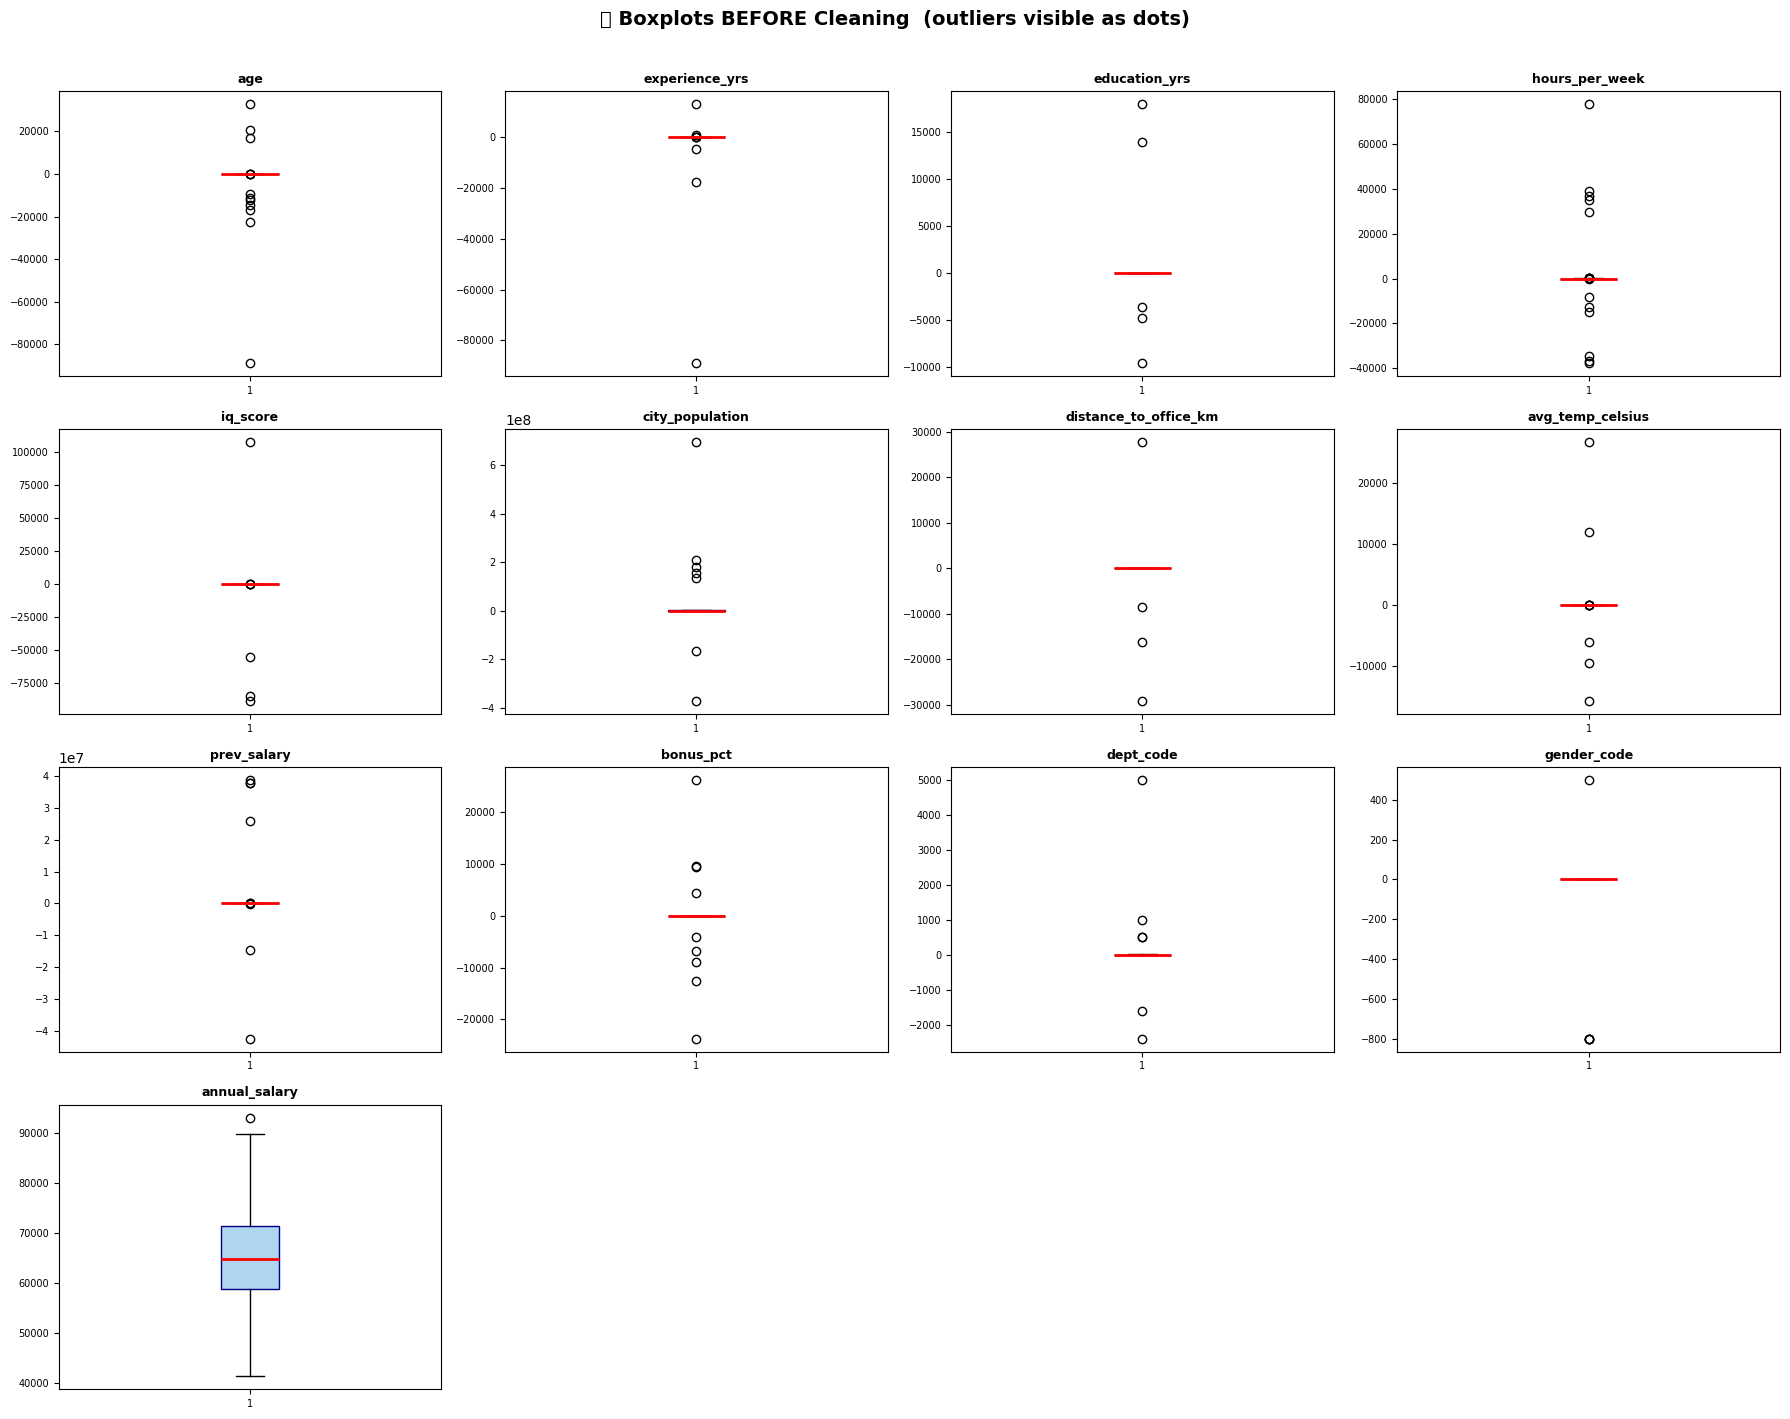


💡 Notice the extreme dots far outside the whiskers — those are the injected outliers.


In [4]:
# ── Convert to numeric silently just for the EDA plot (errors → NaN) ─────────
df_preview = df.copy()
for col in df_preview.columns:
    df_preview[col] = pd.to_numeric(df_preview[col], errors='coerce')

numeric_cols = df_preview.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_preview[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("📦 Boxplots BEFORE Cleaning  (outliers visible as dots)", 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("boxplots_before_cleaning.png", dpi=120, bbox_inches='tight')
plt.show()
print("\n💡 Notice the extreme dots far outside the whiskers — those are the injected outliers.")


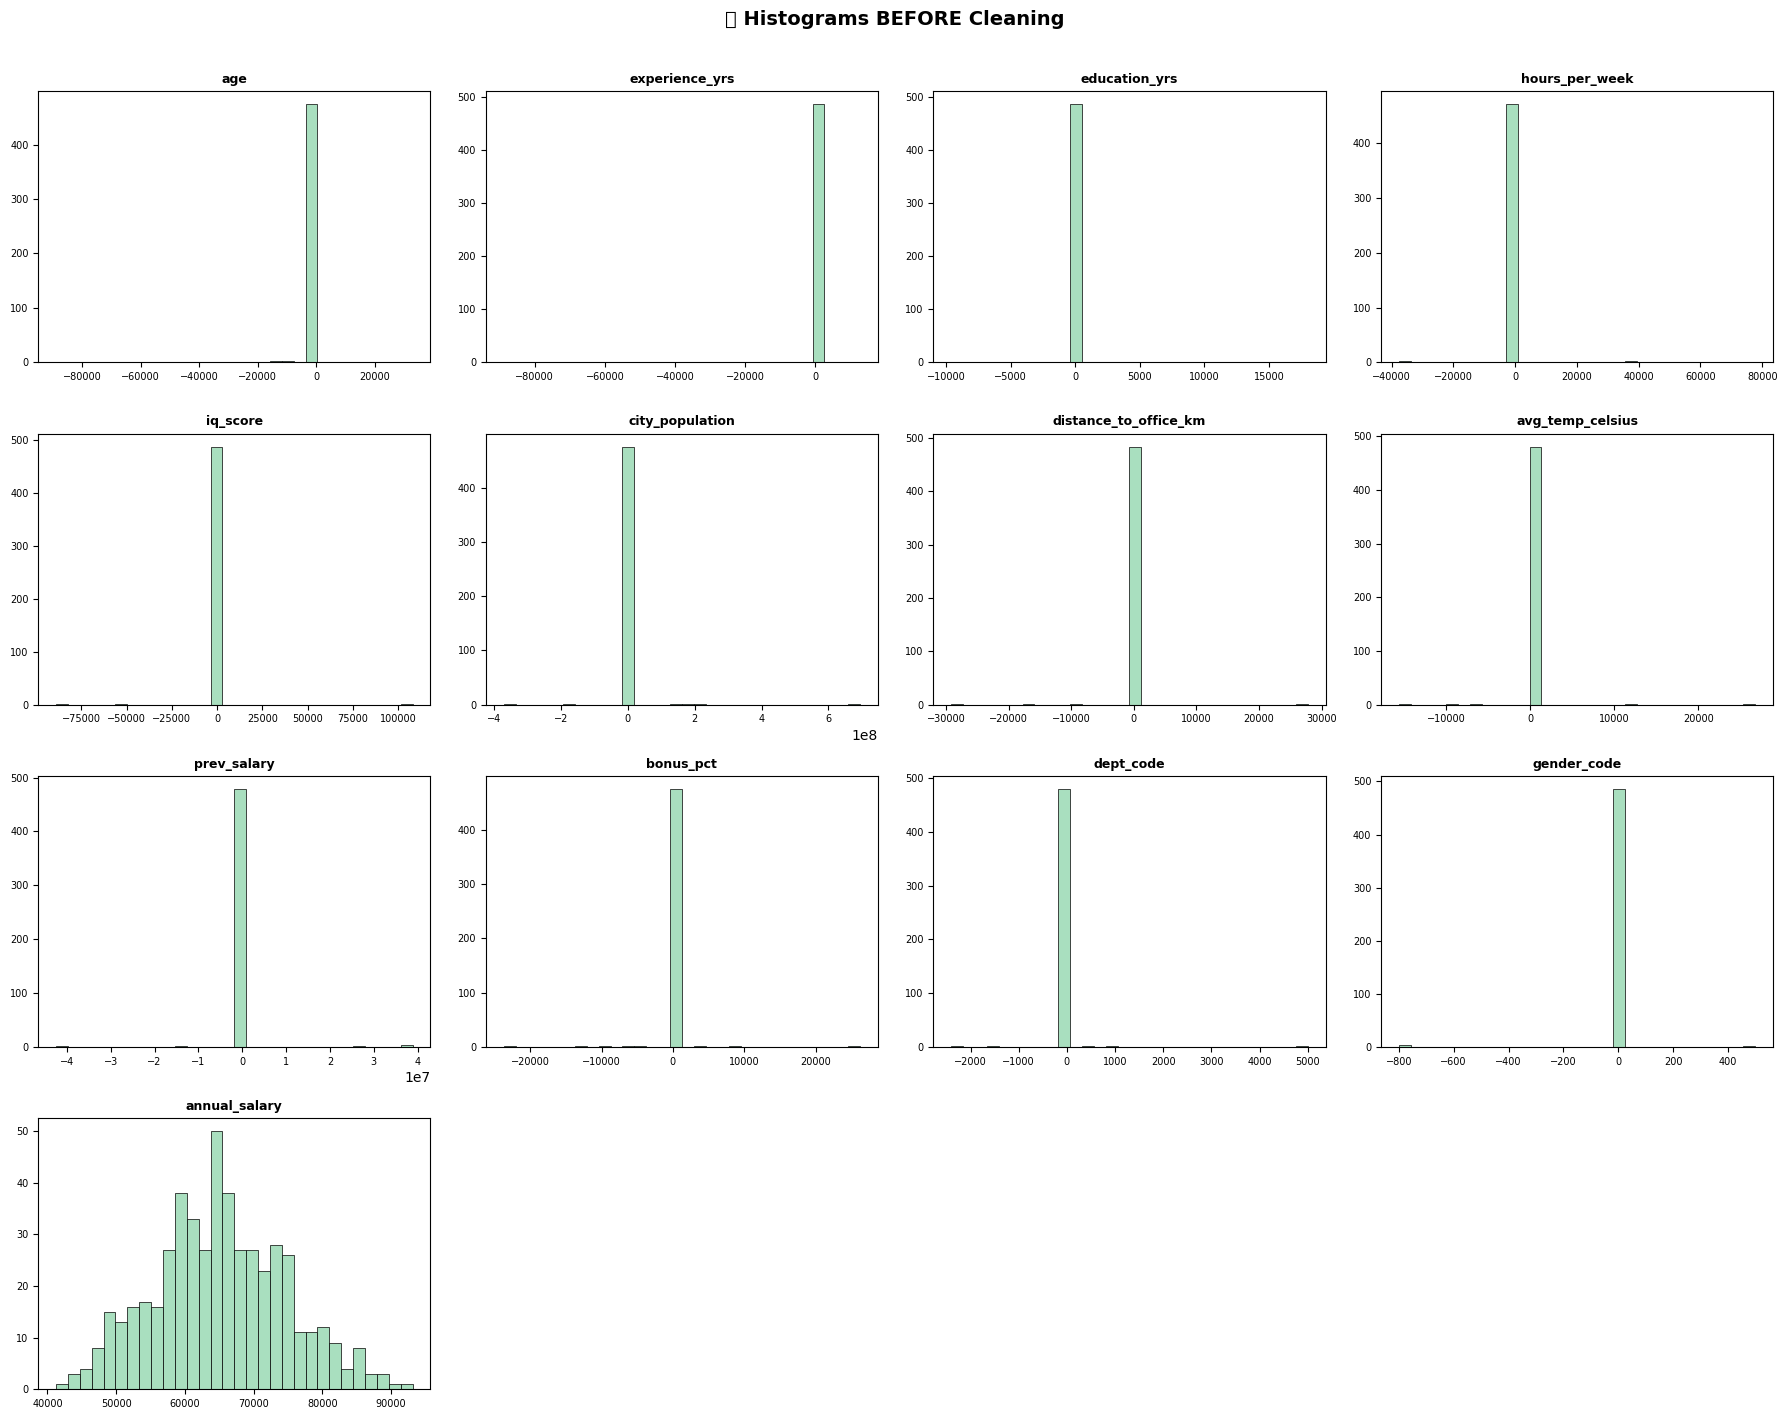

In [5]:
# ── Histograms before cleaning ────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_preview[col].dropna(), bins=30, color='#A9DFBF', edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("📊 Histograms BEFORE Cleaning", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("histograms_before_cleaning.png", dpi=120, bbox_inches='tight')
plt.show()


---
## Step 1 · Detect & Replace Junk / Non-Numeric Values

Junk tokens are strings like `?`, `-`, `N/A`, `#`, `null`, etc.  
**Strategy:** Try to cast every cell value to `float`. If it fails → it's junk → replace with `NaN`.


In [6]:
# ── Pass 1: scan all columns, collect every unique junk token ─────────────────
junk_values = set(['', ' '])   # seed with common invisibles

for column in df.columns:
    for value, count in df[column].value_counts().items():
        try:
            float(value)        # if this succeeds, it's a valid number → keep
        except (ValueError, TypeError):
            junk_values.add(value)
            print(f"  [{column}]  →  '{value}'  (occurs {count}×)")

print(f"\n🗑️  Total unique junk tokens found: {len(junk_values)}")
print(f"   Tokens: {junk_values}")


  [age]  →  '##'  (occurs 2×)
  [age]  →  '#'  (occurs 2×)
  [age]  →  '-'  (occurs 1×)
  [experience_yrs]  →  '--'  (occurs 3×)
  [experience_yrs]  →  '-'  (occurs 2×)
  [experience_yrs]  →  '?'  (occurs 1×)
  [experience_yrs]  →  '##'  (occurs 1×)
  [education_yrs]  →  '#'  (occurs 1×)
  [hours_per_week]  →  '#'  (occurs 4×)
  [hours_per_week]  →  '##'  (occurs 1×)
  [iq_score]  →  '?'  (occurs 1×)
  [iq_score]  →  '#'  (occurs 1×)
  [iq_score]  →  '--'  (occurs 1×)
  [city_population]  →  '--'  (occurs 3×)
  [city_population]  →  '?'  (occurs 2×)
  [city_population]  →  '##'  (occurs 1×)
  [city_population]  →  '#'  (occurs 1×)
  [distance_to_office_km]  →  '##'  (occurs 1×)
  [distance_to_office_km]  →  '--'  (occurs 1×)
  [distance_to_office_km]  →  '-'  (occurs 1×)
  [avg_temp_celsius]  →  '#'  (occurs 2×)
  [avg_temp_celsius]  →  '--'  (occurs 1×)
  [avg_temp_celsius]  →  '-'  (occurs 1×)
  [prev_salary]  →  '?'  (occurs 1×)
  [prev_salary]  →  '#'  (occurs 1×)
  [bonus_pct]  → 

In [7]:
# ── Replace every junk token with proper NaN ─────────────────────────────────
df = df.replace(list(junk_values), np.nan)

# ── Verify: re-scan, should print nothing ─────────────────────────────────────
found_junk = False
for column in df.columns:
    for value in df[column].value_counts().index:
        try:
            float(value)
        except (ValueError, TypeError):
            print(f"  Still junk in [{column}]: '{value}'")
            found_junk = True

if not found_junk:
    print("✅ Zero junk tokens remaining. All non-numerics are now NaN.")


✅ Zero junk tokens remaining. All non-numerics are now NaN.


---
## Step 2 · Type Coercion — Convert Everything to Numeric

After junk removal, all columns are still `object` (string) dtype.  
`pd.to_numeric(..., errors='coerce')` converts safely — anything it can't parse becomes `NaN`.


In [8]:
# ── Columns you want to keep as text (empty here since all cols are numeric) ──
TEXT_COLUMNS = []

for col in df.columns:
    if col not in TEXT_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("dtypes after coercion:")
print(df.dtypes)
print(f"\nNull counts after type coercion (includes original + newly coerced):")
print(df.isnull().sum())


dtypes after coercion:
age                      float64
experience_yrs           float64
education_yrs            float64
hours_per_week           float64
iq_score                 float64
city_population          float64
distance_to_office_km    float64
avg_temp_celsius         float64
prev_salary              float64
bonus_pct                float64
dept_code                float64
gender_code              float64
annual_salary            float64
dtype: object

Null counts after type coercion (includes original + newly coerced):
age                      16
experience_yrs           10
education_yrs             9
hours_per_week           18
iq_score                  8
city_population          17
distance_to_office_km    12
avg_temp_celsius         14
prev_salary              15
bonus_pct                16
dept_code                14
gender_code               9
annual_salary             0
dtype: int64


---
## Step 3 · Handle Negative Values

Certain columns (age, salary, distance…) can **never** be negative.  
Negative values here are either data-entry errors or injected junk — treat them as `NaN`.


In [9]:
# ── Which columns have negatives? ─────────────────────────────────────────────
print("Columns with at least one negative value:")
for col in df.columns:
    neg_mask = df[col] < 0
    if neg_mask.any():
        print(f"  {col}: {neg_mask.sum()} negative rows  |  values: {df[col][neg_mask].values}")


Columns with at least one negative value:
  age: 7 negative rows  |  values: [-22400. -16960. -12120. -11220. -88888.  -9270. -14700.]
  experience_yrs: 3 negative rows  |  values: [-17680.  -4720. -88888.]
  education_yrs: 3 negative rows  |  values: [-4800. -3600. -9600.]
  hours_per_week: 6 negative rows  |  values: [-14970. -37680. -36960. -12840.  -8280. -34640.]
  iq_score: 3 negative rows  |  values: [-88888.  -55555.5 -84960. ]
  city_population: 3 negative rows  |  values: [-3.717184e+08 -2.201700e+04 -1.669476e+08]
  distance_to_office_km: 3 negative rows  |  values: [-16184. -29168.  -8613.]
  avg_temp_celsius: 4 negative rows  |  values: [-1.5632e+04 -5.9430e+03 -9.4640e+03 -1.5300e+00]
  prev_salary: 3 negative rows  |  values: [   -88888. -14606796. -42491688.]
  bonus_pct: 5 negative rows  |  values: [-12624.  -6765. -23720.  -8949.  -4119.]
  dept_code: 2 negative rows  |  values: [-1600. -2400.]
  gender_code: 4 negative rows  |  values: [-800. -800. -800. -800.]


In [10]:
# ── METHOD 1 (recommended): Replace negatives in the ENTIRE dataframe at once ─
df[df < 0] = np.nan

# ── METHOD 2: Only specific columns (commented out — pick what suits your data)
# cols_no_neg = ['age', 'experience_yrs', 'prev_salary', 'annual_salary']
# df[cols_no_neg] = df[cols_no_neg].mask(df[cols_no_neg] < 0, np.nan)

# ── METHOD 3: Single column ────────────────────────────────────────────────────
# df['age'] = df['age'].mask(df['age'] < 0, np.nan)

# ── Verify ────────────────────────────────────────────────────────────────────
still_neg = [(col, (df[col] < 0).sum()) for col in df.columns if (df[col] < 0).any()]
if still_neg:
    print("Still negative:", still_neg)
else:
    print("✅ No negative values remain.")


✅ No negative values remain.


---
## Step 4 · Domain Constraint Validation

Even after removing negatives, values can be *numerically valid* but *domain-invalid*  
(e.g. `age = 999999`, `iq_score = 77777`).

Define a realistic `(min, max)` range for each column and null out violations.


In [11]:
# ── Define realistic domain constraints for each column ───────────────────────
# Format: 'column_name': (min_valid, max_valid)
CONSTRAINTS = {
    'age'                   : (0,   120),
    'experience_yrs'        : (0,    60),
    'education_yrs'         : (0,    30),
    'hours_per_week'        : (0,   168),   # max hours in a week
    'iq_score'              : (40,  200),
    'city_population'       : (0,   1_400_000_000),
    'distance_to_office_km' : (0,   1_000),
    'avg_temp_celsius'      : (-60,  60),
    'prev_salary'           : (0,   1_000_000_000),
    'bonus_pct'             : (0,   100),
    'dept_code'             : (1,   5),
    'gender_code'           : (0,   1),
    'annual_salary'         : (0,   1_000_000_000),
}

# ── Report violations before replacing ────────────────────────────────────────
print("Constraint violations found:")
total_violations = 0
for col, (lo, hi) in CONSTRAINTS.items():
    mask = (df[col] < lo) | (df[col] > hi)
    n = mask.sum()
    total_violations += n
    if n:
        print(f"  {col}: {n} violations  |  values: {df[col][mask].values}")

print(f"\nTotal violations: {total_violations}")


Constraint violations found:
  age: 3 violations  |  values: [16800. 32800. 20850.]
  experience_yrs: 2 violations  |  values: [  900. 12800.]
  education_yrs: 2 violations  |  values: [18000. 14000.]
  hours_per_week: 5 violations  |  values: [36700.  34900.  38900.  29600.  77777.7]
  iq_score: 1 violations  |  values: [107800.]
  distance_to_office_km: 1 violations  |  values: [27780.]
  avg_temp_celsius: 2 violations  |  values: [12120. 26790.]
  bonus_pct: 4 violations  |  values: [ 4390.  9580. 26240.  9470.]
  dept_code: 4 violations  |  values: [ 500. 5000. 1000.  500.]
  gender_code: 1 violations  |  values: [500.]

Total violations: 25


In [12]:
# ── Replace all violations with NaN ───────────────────────────────────────────
for col, (lo, hi) in CONSTRAINTS.items():
    df[col] = df[col].mask(
        (df[col] < lo) | (df[col] > hi),
        np.nan
    )

# ── Verify ────────────────────────────────────────────────────────────────────
remaining = 0
for col, (lo, hi) in CONSTRAINTS.items():
    n = ((df[col] < lo) | (df[col] > hi)).sum()
    remaining += n
if remaining == 0:
    print("✅ All constraint violations replaced with NaN.")
else:
    print(f"⚠️  {remaining} violations still present — check your constraints dict.")


✅ All constraint violations replaced with NaN.


---
## Step 5 · Duplicate Row Detection & Removal

Duplicate rows can silently bias a model by over-representing certain patterns.  
Always check — even if you expect none.


In [13]:
# ── Full-row duplicates ───────────────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"Full-row duplicates: {dup_count}")

if dup_count > 0:
    print(df[df.duplicated()])
    df = df.drop_duplicates()
    print(f"✅ Removed {dup_count} duplicate rows. New shape: {df.shape}")
else:
    print("✅ No duplicate rows found.")

# ── If you have a unique ID column, check that instead ────────────────────────
# Example (commented out — adapt as needed):
# dup_by_id = df[df.duplicated(subset=['employee_id'])]
# df = df.drop_duplicates(subset=['employee_id'])


Full-row duplicates: 0
✅ No duplicate rows found.


---
## Step 6 · Missing Value Imputation

Now that all junk, outliers, and constraint violations are `NaN`, we handle them properly.

| Column type | Strategy | Why |
|---|---|---|
| Continuous numeric | **Median** | Robust to remaining outliers |
| Categorical / code | **Mode** | Most frequent category is safest guess |
| Text | `'Unknown'` or keep NaN | Mean/median meaningless for strings |
| IDs | **Drop the row** | Never impute — IDs must be unique |

> 📌 **Note:** For time-series data, use `ffill` / `bfill` / `interpolate` instead.


In [14]:
# ── Check null counts before imputation ───────────────────────────────────────
null_before = df.isnull().sum()
print("Null counts before imputation:")
print(null_before[null_before > 0])
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


Null counts before imputation:
age                      26
experience_yrs           15
education_yrs            14
hours_per_week           29
iq_score                 12
city_population          20
distance_to_office_km    16
avg_temp_celsius         20
prev_salary              18
bonus_pct                25
dept_code                20
gender_code              14
dtype: int64

Total missing cells: 229


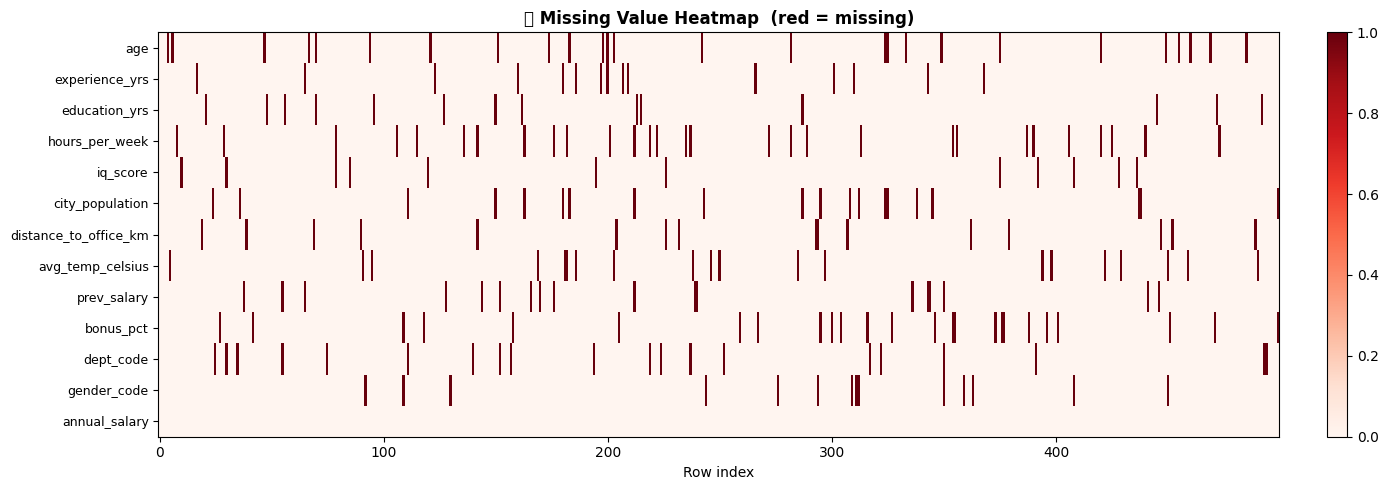

In [15]:
# ── Visualise missing values as a heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
null_map = df.isnull().astype(int)
im = ax.imshow(null_map.T, aspect='auto', cmap='Reds', interpolation='none')
ax.set_yticks(range(len(df.columns)))
ax.set_yticklabels(df.columns, fontsize=9)
ax.set_xlabel("Row index", fontsize=10)
ax.set_title("🔴 Missing Value Heatmap  (red = missing)", fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
plt.tight_layout()
plt.savefig("missing_value_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()


In [16]:
# ── Impute continuous columns with MEDIAN ─────────────────────────────────────
CONTINUOUS_COLS = [
    'age', 'experience_yrs', 'education_yrs', 'hours_per_week',
    'iq_score', 'city_population', 'distance_to_office_km',
    'avg_temp_celsius', 'prev_salary', 'bonus_pct', 'annual_salary'
]

# ── Impute categorical columns with MODE ──────────────────────────────────────
CATEGORICAL_COLS = ['dept_code', 'gender_code']

for col in CONTINUOUS_COLS:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

for col in CATEGORICAL_COLS:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

# ── Verify ────────────────────────────────────────────────────────────────────
total_null = df.isnull().sum().sum()
print(f"Total null values after imputation: {total_null}")
if total_null == 0:
    print("✅ All missing values have been filled.")


Total null values after imputation: 0
✅ All missing values have been filled.


---
## Step 7 · Cleaning Summary Report

A single summary cell that confirms the dataset is clean and ready for modelling.


In [17]:
print("=" * 55)
print("         📋 DATA CLEANING SUMMARY REPORT")
print("=" * 55)
print(f"  Final shape          : {df.shape}")
print(f"  Total nulls remaining: {df.isnull().sum().sum()}")
print(f"  Negative values      : {(df < 0).sum().sum()}")
print(f"  Duplicate rows       : {df.duplicated().sum()}")
print(f"  All dtypes numeric   : {all(df.dtypes != object)}")
print("=" * 55)
print("\nColumn summary:")
summary = pd.DataFrame({
    'dtype'   : df.dtypes,
    'nulls'   : df.isnull().sum(),
    'min'     : df.min(),
    'max'     : df.max(),
    'mean'    : df.mean().round(2),
    'median'  : df.median().round(2),
})
print(summary.to_string())


         📋 DATA CLEANING SUMMARY REPORT
  Final shape          : (500, 13)
  Total nulls remaining: 0
  Negative values      : 0
  Duplicate rows       : 0
  All dtypes numeric   : True

Column summary:
                         dtype  nulls      min          max       mean    median
age                    float64      0     6.80        63.40      35.01     35.55
experience_yrs         float64      0     0.00        41.00      13.33     13.30
education_yrs          float64      0    10.00        20.00      15.31     16.00
hours_per_week         float64      0    18.70        67.60      40.15     40.20
iq_score               float64      0    59.00       143.50     100.36    100.40
city_population        float64      0  5714.00 694764000.00 3237842.21 496892.00
distance_to_office_km  float64      0     0.49        46.44      19.95     19.44
avg_temp_celsius       float64      0     3.36        42.04      21.91     21.38
prev_salary            float64      0  8390.25  38820340.00  325016.

---
## Step 8 · Visual EDA  *(After Cleaning)*

Compare these plots to the ones in Step 3.  
The extreme outlier dots in the boxplots should be **gone** — distributions should look sensible.


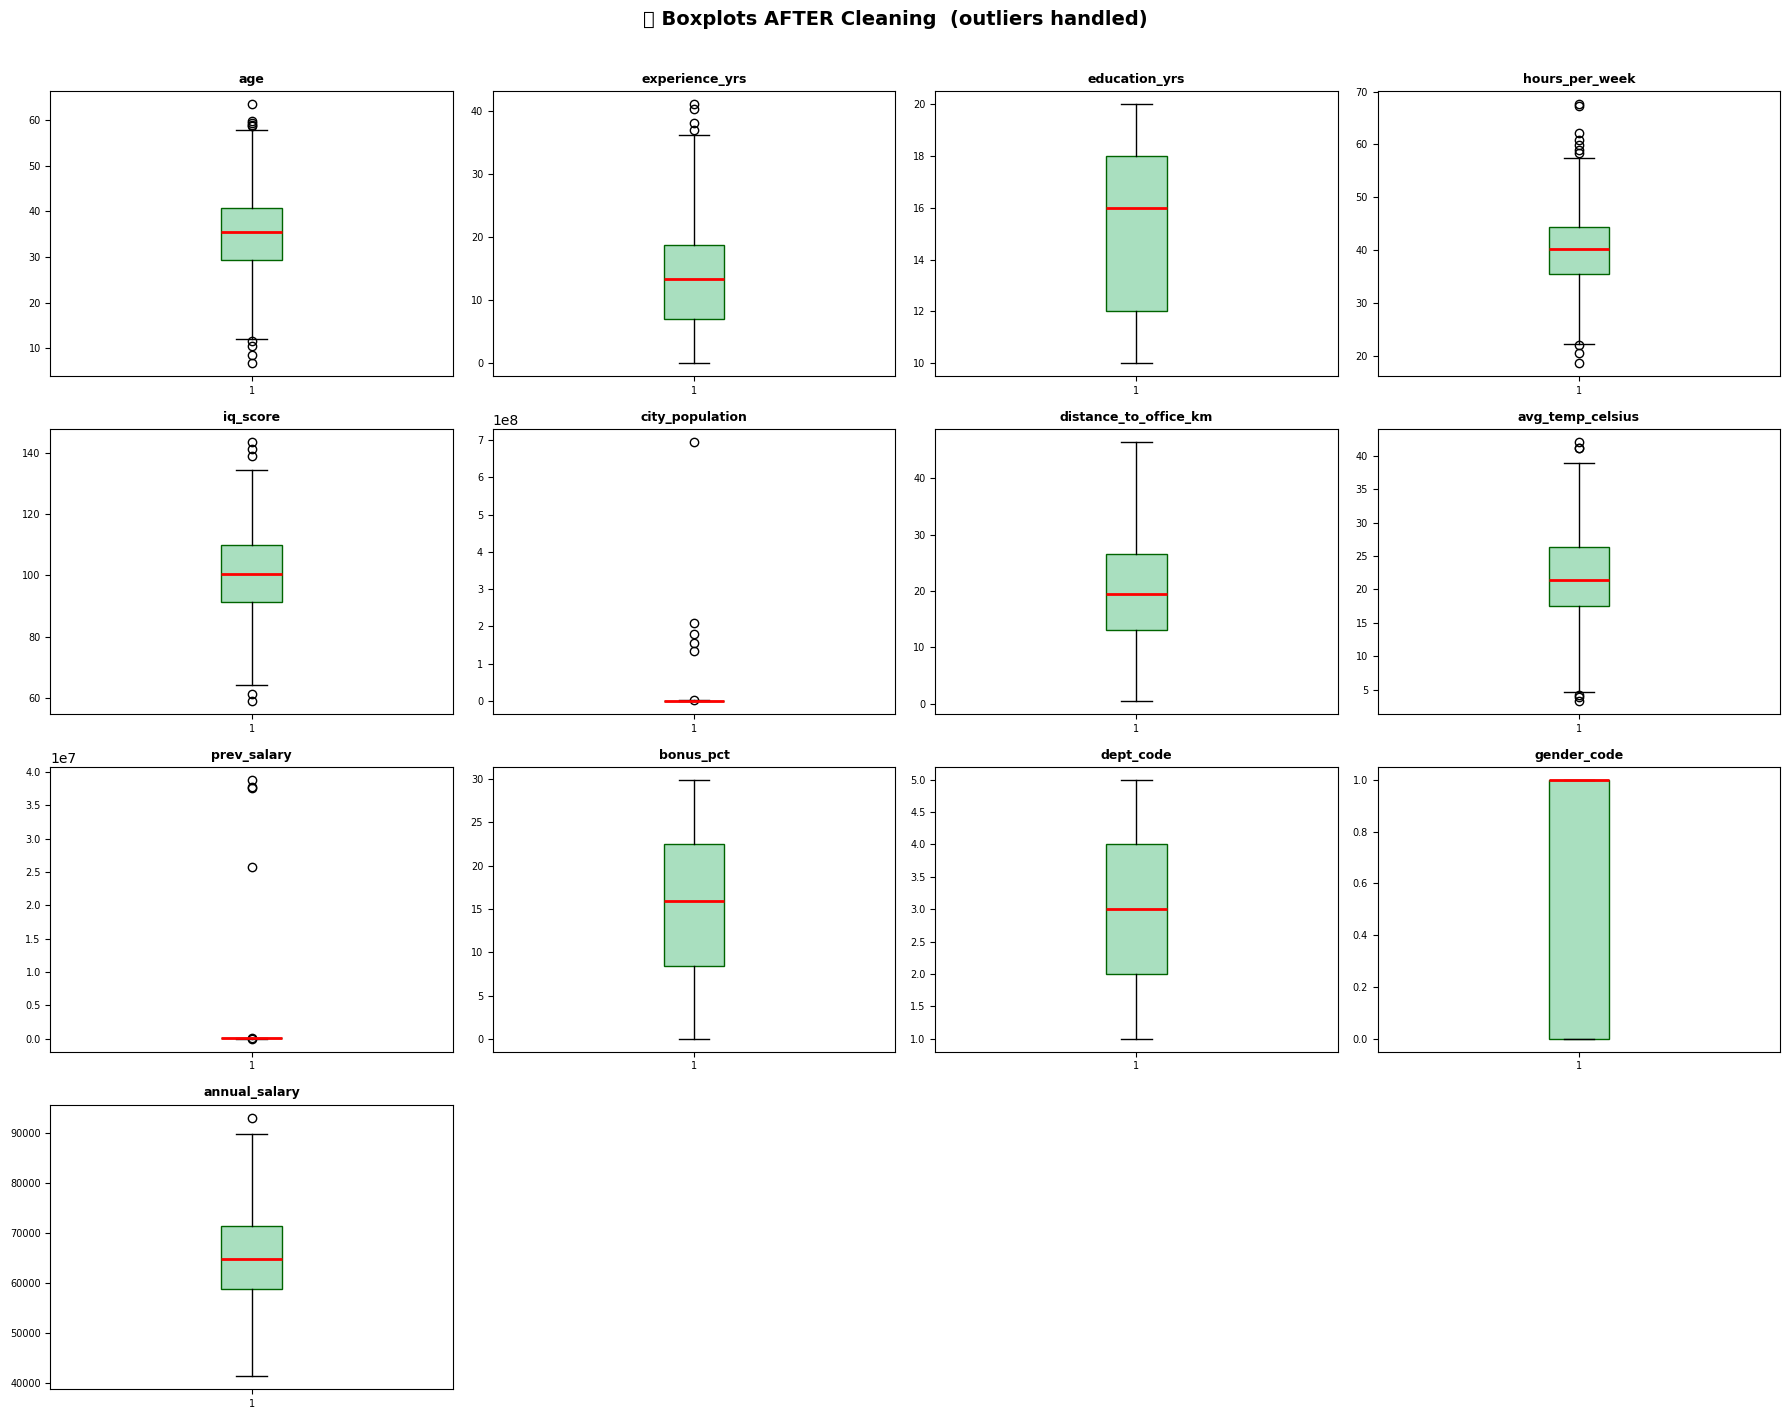

In [18]:
numeric_cols_clean = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_clean):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#A9DFBF', color='darkgreen'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)

for j in range(len(numeric_cols_clean), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("📦 Boxplots AFTER Cleaning  (outliers handled)", 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("boxplots_after_cleaning.png", dpi=120, bbox_inches='tight')
plt.show()


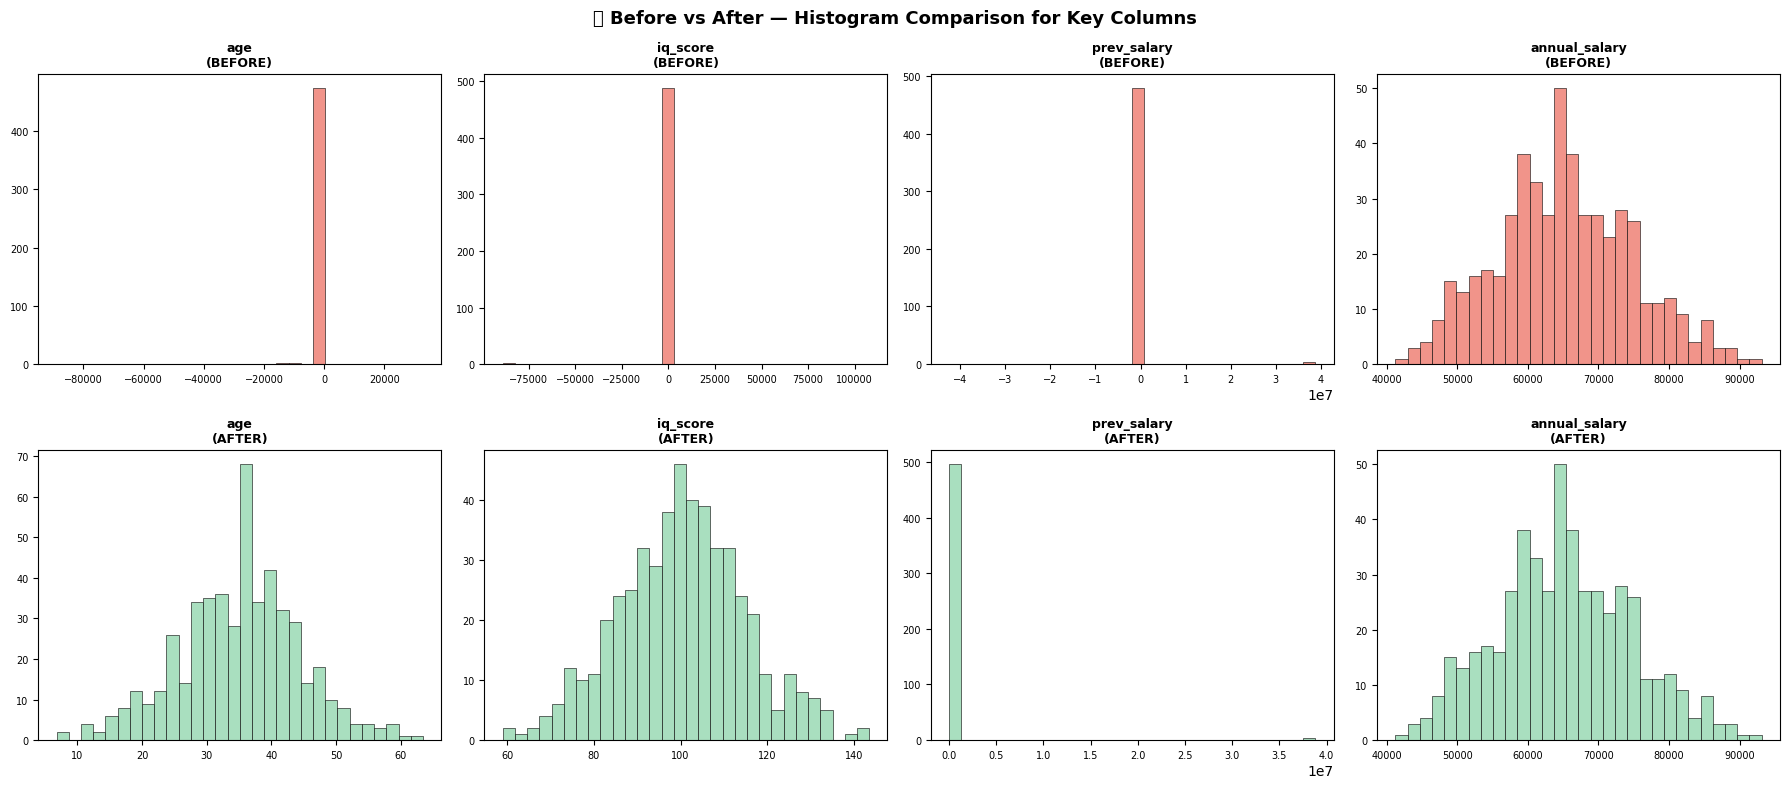

In [19]:
# ── Histogram comparison (before vs after) for key columns ───────────────────
KEY_COLS = ['age', 'iq_score', 'prev_salary', 'annual_salary']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))

for i, col in enumerate(KEY_COLS):
    # Before (from df_preview)
    axes[0, i].hist(df_preview[col].dropna(), bins=30, color='#F1948A', edgecolor='black', lw=0.4)
    axes[0, i].set_title(f"{col}\n(BEFORE)", fontsize=9, fontweight='bold')
    axes[0, i].tick_params(labelsize=7)

    # After
    axes[1, i].hist(df[col].dropna(), bins=30, color='#A9DFBF', edgecolor='black', lw=0.4)
    axes[1, i].set_title(f"{col}\n(AFTER)", fontsize=9, fontweight='bold')
    axes[1, i].tick_params(labelsize=7)

fig.suptitle("📊 Before vs After — Histogram Comparison for Key Columns", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("histograms_before_vs_after.png", dpi=120, bbox_inches='tight')
plt.show()


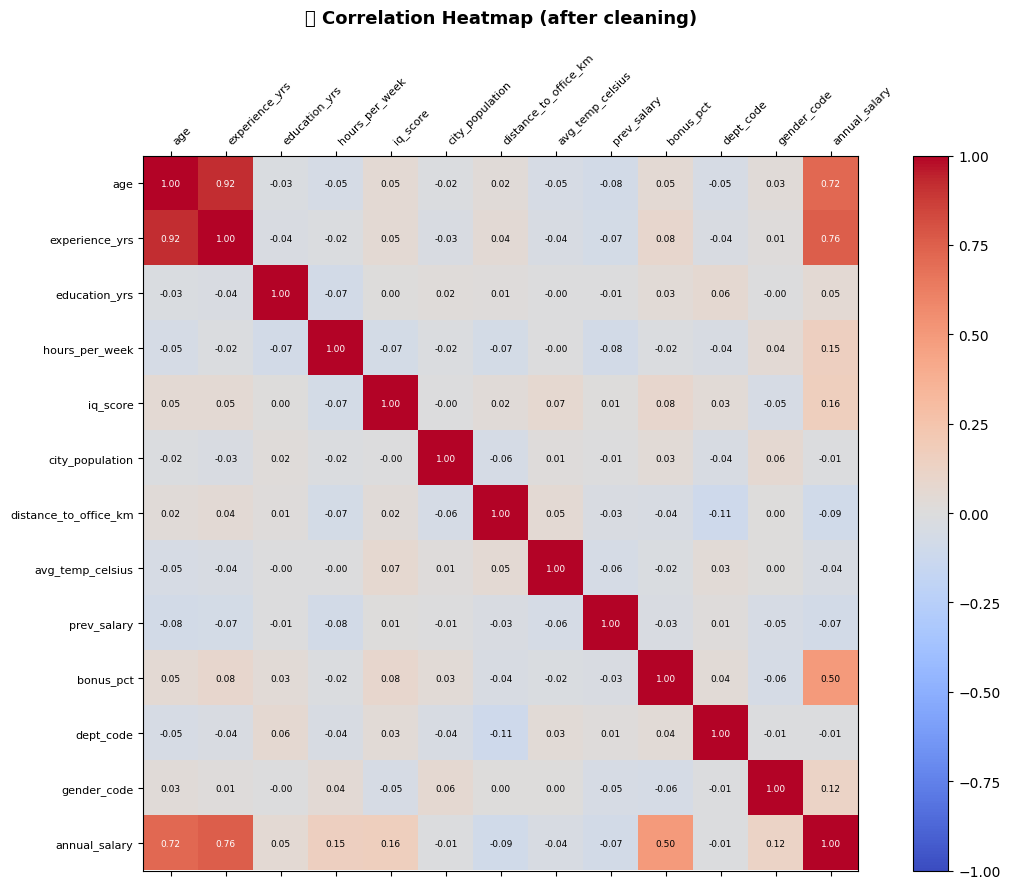


💡 High correlation with annual_salary = strong regression predictor.


In [20]:
# ── Correlation heatmap on clean data ─────────────────────────────────────────
import matplotlib.colors as mcolors

corr = df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='left', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

# Annotate each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=6.5,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')

ax.set_title("🔗 Correlation Heatmap (after cleaning)", fontsize=13, 
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()
print("\n💡 High correlation with annual_salary = strong regression predictor.")


---
## Step 9 · Export Cleaned Data

Save in two formats:
- **CSV** — universal, human-readable, loses float precision on very large numbers
- **Parquet** — preserves exact dtypes and is much faster to reload in Python

> Always save parquet for your ML pipeline and CSV for sharing/inspection.


In [21]:
# ── Save as CSV ───────────────────────────────────────────────────────────────
CSV_OUT = "ml_dataset_cleaned.csv"
df.to_csv(CSV_OUT, index=False)

# ── Save as Parquet (preserves dtypes) ────────────────────────────────────────
PARQUET_OUT = "ml_dataset_cleaned.parquet"

try:
    df.to_parquet(PARQUET_OUT, engine='fastparquet', index=False)
    print(f"✅ Saved CSV     → {CSV_OUT}")
    print(f"✅ Saved Parquet → {PARQUET_OUT}")
except Exception as e:
    df.to_parquet(PARQUET_OUT, engine='pyarrow', index=False)
    print(f"✅ Saved (pyarrow fallback) → {PARQUET_OUT}")


✅ Saved CSV     → ml_dataset_cleaned.csv
✅ Saved Parquet → ml_dataset_cleaned.parquet


In [22]:
# ── Verify: reload both and compare dtypes ────────────────────────────────────
reload_csv     = pd.read_csv(CSV_OUT)
reload_parquet = pd.read_parquet(PARQUET_OUT)

compare = pd.DataFrame({
    'cleaned_df'     : df.dtypes,
    'reloaded_csv'   : reload_csv.dtypes,
    'reloaded_parquet': reload_parquet.dtypes,
})
print("Dtype comparison — CSV loses some precision, Parquet preserves exactly:")
print(compare.to_string())


Dtype comparison — CSV loses some precision, Parquet preserves exactly:
                      cleaned_df reloaded_csv reloaded_parquet
age                      float64      float64          float64
experience_yrs           float64      float64          float64
education_yrs            float64      float64          float64
hours_per_week           float64      float64          float64
iq_score                 float64      float64          float64
city_population          float64      float64          float64
distance_to_office_km    float64      float64          float64
avg_temp_celsius         float64      float64          float64
prev_salary              float64      float64          float64
bonus_pct                float64      float64          float64
dept_code                float64      float64          float64
gender_code              float64      float64          float64
annual_salary            float64      float64          float64


---
## 📖 Quick Reference — When to Use What

### Missing Value Strategies

| Data Type | Best Strategy | Code |
|---|---|---|
| Continuous numeric (normal dist) | Mean | `df[col].fillna(df[col].mean())` |
| Continuous numeric (skewed/outliers) | **Median** | `df[col].fillna(df[col].median())` |
| Categorical / code | **Mode** | `df[col].fillna(df[col].mode()[0])` |
| Free text | Placeholder | `df[col].fillna('Unknown')` |
| Time series | Forward fill | `df[col].fillna(method='ffill')` |
| Time series | Backward fill | `df[col].fillna(method='bfill')` |
| Time series | Interpolate | `df[col].interpolate()` |
| IDs / keys | **Drop the row** | `df.dropna(subset=['id_col'])` |
| Boolean | False or Mode | `df[col].fillna(False)` |

### Junk Token Detection
```python
junk_values = set(['', ' '])
for col in df.columns:
    for val in df[col].value_counts().index:
        try:
            float(val)
        except:
            junk_values.add(val)
df = df.replace(list(junk_values), np.nan)
```

### Constraint Violation Replacement
```python
df['age'] = df['age'].mask((df['age'] < 0) | (df['age'] > 120), np.nan)
```

### Duplicate Removal
```python
df = df.drop_duplicates()                          # full row
df = df.drop_duplicates(subset=['employee_id'])    # by key column
```

### Export
```python
df.to_csv('clean.csv', index=False)
df.to_parquet('clean.parquet', engine='fastparquet')
```

---
*Next step → Data Standardisation (StandardScaler / MinMaxScaler) → then Regression Models.*
